# **Preparing Dependancies**

In [1]:
!pip install -q diffusers transformers accelerate safetensors
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:0000

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#modul diffusers
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    EulerAncestralDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

# Memuat pipeline Text-to-Image
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    dtype=torch.float16, 
    use_safetensors=True,
    safety_checker=None
)
 
# Memindahkan proses ke GPU (CUDA)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

## **Load Base Pipeline Model**

In [4]:
prompt = """a white spacesuit astronaut with black visor standing on a wide flat reddish brown sandy terrain, 
Earth visible as a detailed globe in the upper right corner against a starry black sky, 
hard shadow beneath the astronaut, horizon visible in the background,
2D cartoonish animation flat illustration style with thick clean outlines, clean digital art"""
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
seed_value = 222

def generate_simple_image(prompt, negative_prompt, seed_value):
    generator = torch.Generator("cuda").manual_seed(seed_value)
    return pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator
    ).images[0]

def generate_advanced_image(prompt, negative_prompt, seed_value, guidance_scale=5.0, num_inference_steps=70):
    generator = torch.Generator("cuda").manual_seed(seed_value)
    return pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps
    ).images[0]



## **Generate Image**

Generating Simple Image


  0%|          | 0/50 [00:00<?, ?it/s]

Generating Advanced Image


  0%|          | 0/70 [00:00<?, ?it/s]

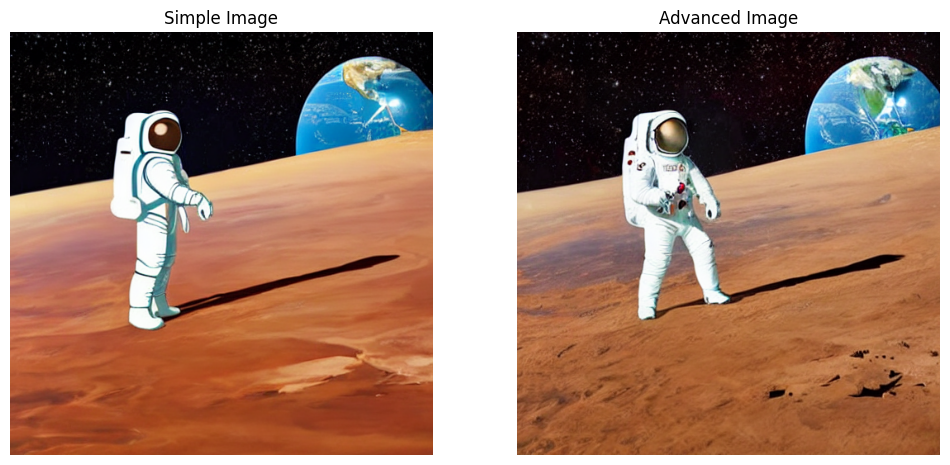

In [5]:
print("Generating Simple Image")
img_simple = generate_simple_image(prompt, negative_prompt, seed_value)

print("Generating Advanced Image")
img_advanced = generate_advanced_image(prompt, negative_prompt, seed_value, guidance_scale=5.0, num_inference_steps=70)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_simple)
axes[0].set_title("Simple Image")
axes[0].axis("off")

axes[1].imshow(img_advanced)
axes[1].set_title("Advanced Image")
axes[1].axis("off")
plt.show()

## **Generate Image with Hyperparameter Configuration**

  0%|          | 0/50 [00:00<?, ?it/s]

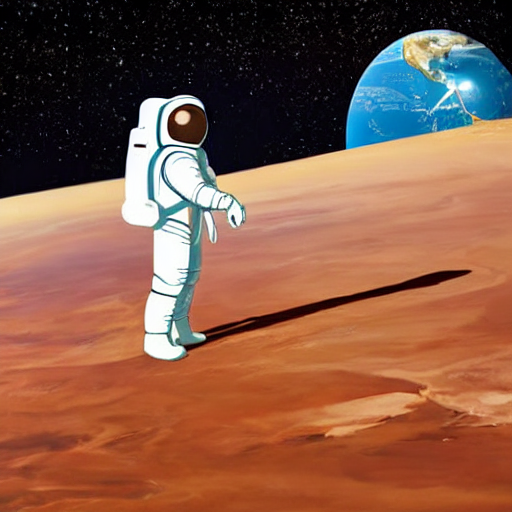

In [6]:
def generate_image(
    prompt,
    negative_prompt,
    seed_value,
    image_type="RGB",        
    guidance_scale=7.5,      
    image_strength=0.5,      
    num_images=1,            
    num_inference_steps=50,  
    fine_tuning=False        
):
    generator = torch.Generator("cuda").manual_seed(seed_value)
    
    images = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=guidance_scale,
        num_images_per_prompt=num_images,
        num_inference_steps=num_inference_steps,
        strength=image_strength if fine_tuning else 1.0
    ).images
    
    # Konversi ke grayscale kalau image_type = "Gray"
    if image_type == "Gray":
        images = [img.convert("L") for img in images]
    
    return images

prompt = """a white spacesuit astronaut with black visor standing on a wide flat reddish brown sandy terrain, 
Earth visible as a detailed globe in the upper right corner against a starry black sky, 
hard shadow beneath the astronaut, horizon visible in the background,
2D cartoonish animation flat illustration style with thick clean outlines, clean digital art"""
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"

imgs = generate_image(prompt, negative_prompt, seed_value)
for img in imgs:
    display(img)

## **Guidance Scale Comparison**

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

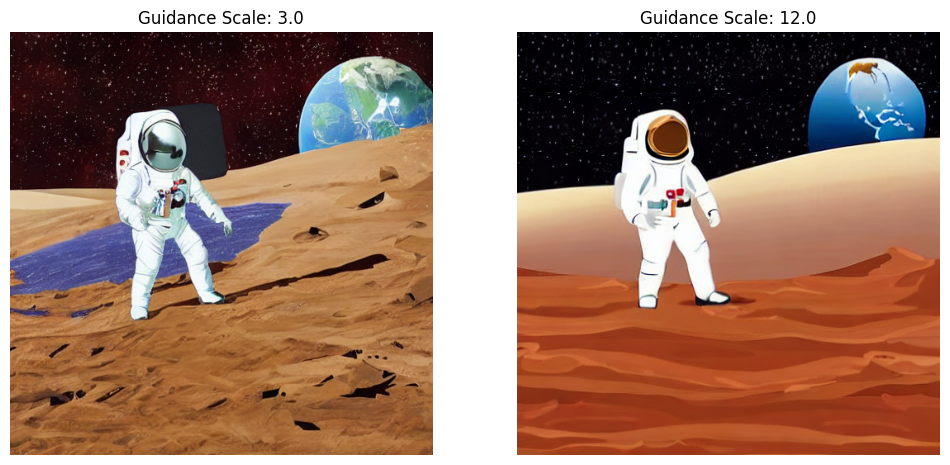

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, gs in enumerate([3.0, 12.0]):
    generator = torch.Generator("cuda").manual_seed(seed_value)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=gs,
        num_inference_steps=30
    ).images[0]
    axes[i].imshow(img)
    axes[i].set_title(f"Guidance Scale: {gs}")
    axes[i].axis("off")

plt.show()

**PENJELASAN**

Gambar yang dihasilkan scale rendah cenderung realistis karena model lebih banyak mengeksplorasi representasi visualnya sebaliknya pada scale tinggi lebih terikat pada prompt, sehingga menghasilkan gaya seperti animasi. Disimpulkan bahwa guidance yang tinggi tidak selalu menghasilkan kualitas yang baik, tetapi lebih ke kepatuhan dan kedekatan pada prompt yang kita tuliskan.

## **Inference Steps Comparison**

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

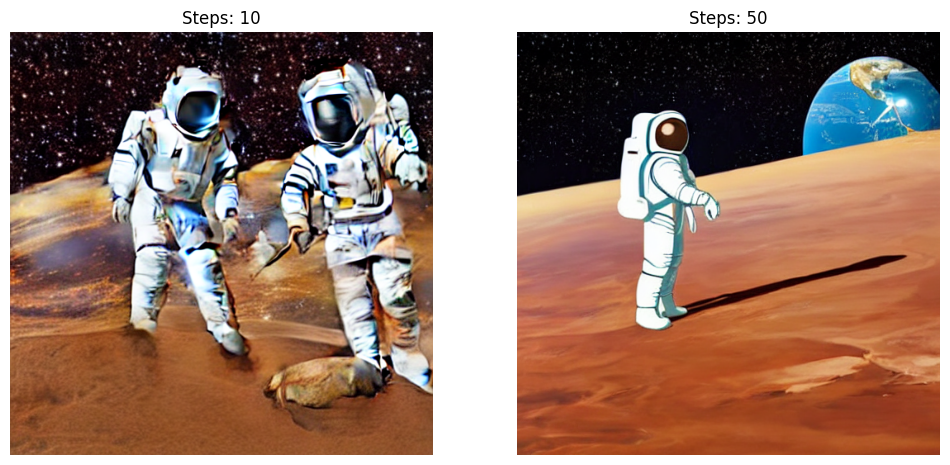

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, steps in enumerate([10, 50]):
    generator = torch.Generator("cuda").manual_seed(seed_value)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=7.5,
        num_inference_steps=steps
    ).images[0]
    axes[i].imshow(img)
    axes[i].set_title(f"Steps: {steps}")
    axes[i].axis("off")

plt.show()

**PENJELASAN**
gambar kurang bersih dihasilkan dengan step rendah, dimana terdapat artefak visual pada baju astronot, warna tidak konsisten, dan detil yang tidak terbentuk dengan bagus, karena proses denoise belum sempurna. Step tinggi menghasilkan gambar yang komposisinya lebih stabil dan natural, detail pakaian astronot juga lebih rapi. Disimpulkan bahwa makin banyak inference steps, maka proses denoise juga makin sempurna.


## **Batch Inference from One Prompt**

  0%|          | 0/30 [00:00<?, ?it/s]

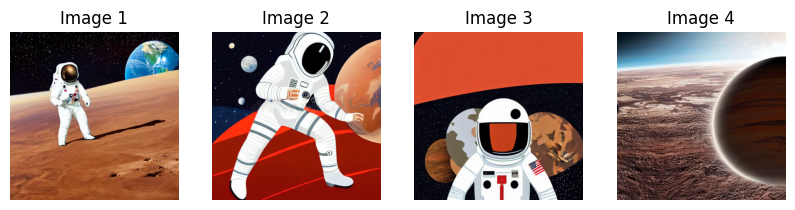

In [9]:
batch_size = 4
generator = torch.Generator("cuda").manual_seed(seed_value)

images = pipe(
    prompt=[prompt] * batch_size,
    negative_prompt=[negative_prompt] * batch_size,
    generator=generator,
    guidance_scale=7.5,
    num_inference_steps=30
).images

fig, axes = plt.subplots(1, batch_size, figsize=(10, 10))
for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.show()

**PENJELASAN**

Batch inference dari satu prompt menghasilkan 4 gambar dengan gaya yang berbeda-beda meskipun prompt sama. Image 1 bergaya semi-realistis dengan latar Mars dan Bumi di langit. Image 2 bergaya ilustrasi flat 2D yang lebih kartun dengan planet-planet berwarna cerah. Image 3 lebih realistis dan sinematik dengan pencahayaan dramatis. Image 4 paling fotorealistis dengan tekstur tanah dan baju astronaut yang sangat detail. Hal ini menunjukkan bahwa model memiliki variasi output yang tinggi dari satu prompt yang sama, karena proses sampling-nya bersifat acak, maka setiap gambar dimulai dari noise yang berbeda.

## **Load Scheduler**

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

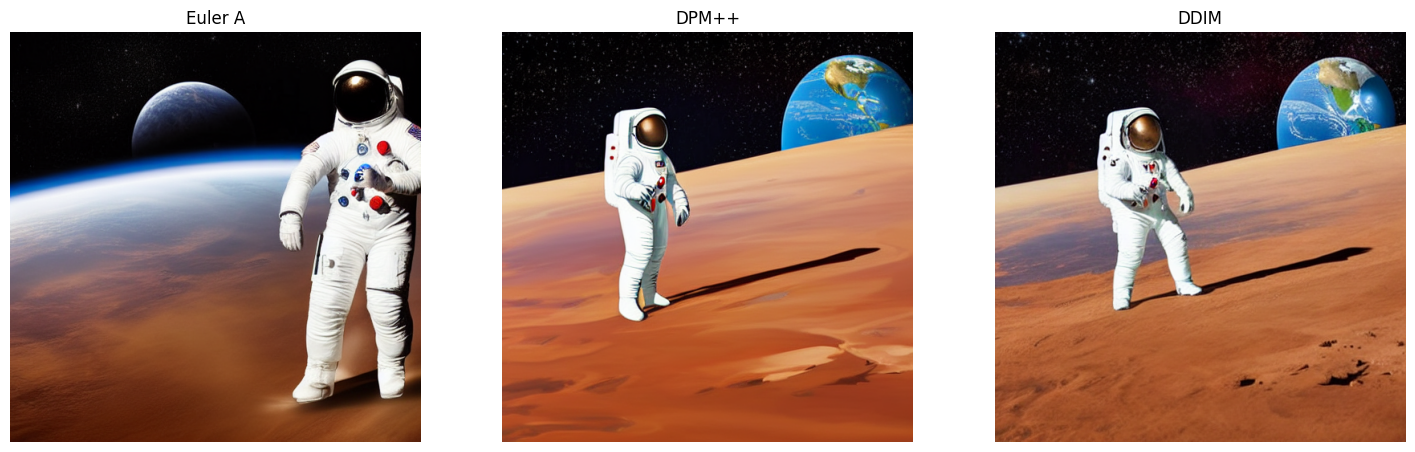

In [23]:
from diffusers import EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler, DDIMScheduler

def load_scheduler(pipe, scheduler_name):
    scheduler_map = {
        "Euler A": EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config),
        "DPM++": DPMSolverMultistepScheduler.from_config(pipe.scheduler.config),
        "DDIM": DDIMScheduler.from_config(pipe.scheduler.config),
    }
    if scheduler_name not in scheduler_map:
        raise ValueError(f"Scheduler '{scheduler_name}' tidak dikenal.")
    pipe.scheduler = scheduler_map[scheduler_name]
    return pipe

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, name in enumerate(["Euler A", "DPM++", "DDIM"]):
    pipe = load_scheduler(pipe, name)
    generator = torch.Generator("cuda").manual_seed(seed_value)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=7.5,
        num_inference_steps=30
    ).images[0]
    axes[i].imshow(img)
    axes[i].set_title(name)
    axes[i].axis("off")

plt.show()

**PENJELASAN**

Ketiga scheduler menghasilkan gaya yang berbeda dari prompt yang sama. 

**Euler A menghasilkan gaya ilustrasi yang lebih artistik dan flat**
astronaut menghadap belakang dengan warna yang lebih solid dan kurang realistis, menunjukkan sifatnya yang lebih eksploratif dan kreatif.

**DPM++ menghasilkan gambar paling realistis dan detail**
tekstur tanah Mars, baju astronaut, dan langit berbintang terlihat tajam dan natural. 

**DDIM menghasilkan hasil yang sangat mirip dengan DPM++**
namun sedikit lebih lembut di detailnya, mencerminkan sifatnya yang deterministik dan stabil. Secara keseluruhan, pilihan scheduler berpengaruh signifikan terhadap gaya visual akhir meskipun prompt dan seed yang digunakan sama.

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

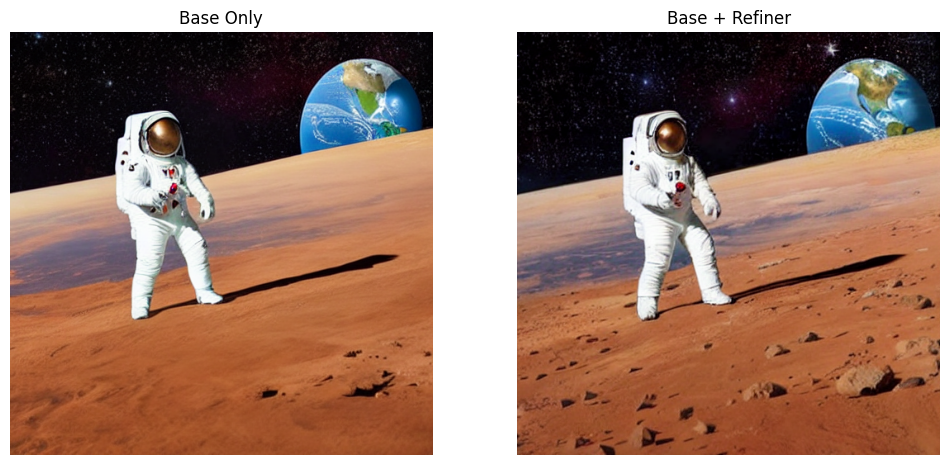

In [11]:
from diffusers import StableDiffusionImg2ImgPipeline

# Pakai model yang sama seperti sebelumnya, tapi pipeline Img2Img
refiner = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Generate base image dulu pakai pipe yang sudah ada
generator = torch.Generator("cuda").manual_seed(seed_value)
base_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    num_inference_steps=30
).images[0]

# Refine
generator = torch.Generator("cuda").manual_seed(seed_value)
refined_image = refiner(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=base_image,
    strength=0.4,
    generator=generator,
    num_inference_steps=30
).images[0]

# Tampilkan
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(base_image)
axes[0].set_title("Base Only")
axes[0].axis("off")

axes[1].imshow(refined_image)
axes[1].set_title("Base + Refiner")
axes[1].axis("off")

plt.show()

## **Inpainting**

### **Load Model Inpainting**

In [12]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### **Manual Masking**

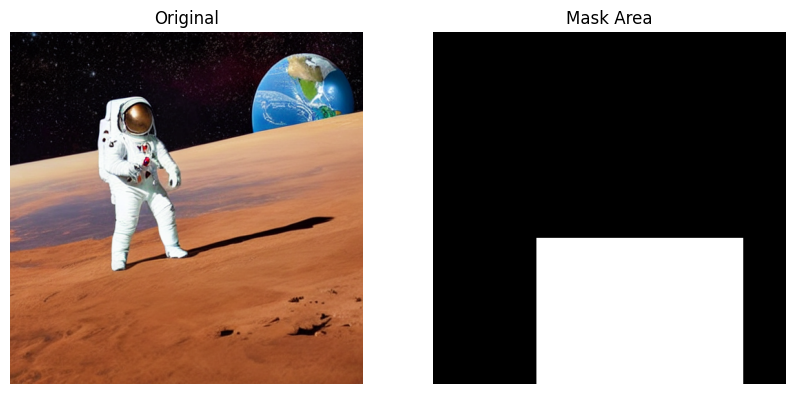

In [13]:
# Fungsi utama
def inpaint_engine(image, mask, prompt, negative_prompt="", seed=9, num_inference_steps=50, guidance_scale=12.0):
    generator = torch.Generator("cuda").manual_seed(seed)
    
    # Pastikan format benar
    image = image.resize((512, 512)).convert("RGB")
    
    # Handle berbagai format mask
    if isinstance(mask, np.ndarray):
        mask = Image.fromarray(mask).convert("L")
    else:
        mask = mask.resize((512, 512)).convert("L")
    
    result = pipe_inpaint(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image,
        mask_image=mask,
        generator=generator,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale
    ).images[0]
    
    return result

# Buat manual mask 
init_image = base_image.resize((512, 512))

mask_array = np.zeros((512, 512), dtype=np.uint8)
mask_array[300:512, 150:450] = 255
mask_pil = Image.fromarray(mask_array).convert("L")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(init_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_pil, cmap="gray")
axes[1].set_title("Mask Area")
axes[1].axis("off")
plt.show()

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

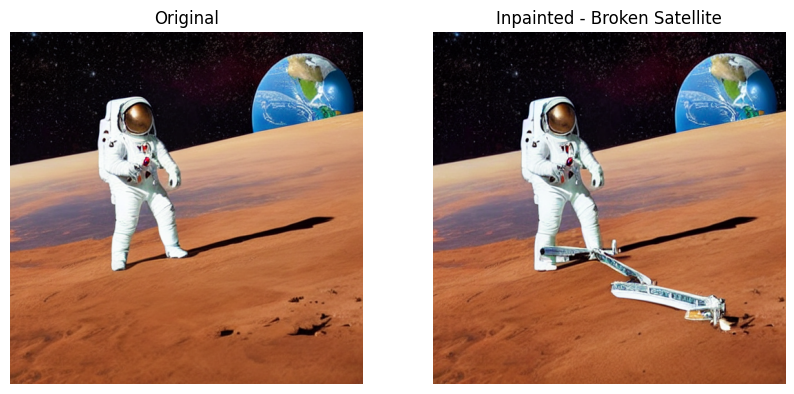

In [14]:
generator = torch.Generator("cuda").manual_seed(9)

result_inpaint = inpaint_engine(
    image=base_image,
    mask=mask_pil,
    prompt="a broken damaged satellite spacecraft crashed on mars ground, bent metallic body, crumpled structure, sci-fi space probe, realistic, detailed",
    negative_prompt="blurry, cartoon, bad quality, deformed, person, human, astronaut, explosion, rubble, solar panel only, flat panel",
    seed=9,
    num_inference_steps=50,
    guidance_scale=20.0
)

# Visualisasi di bawahnya tetap sama seperti sebelumnya
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(base_image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(result_inpaint)
axes[1].set_title("Inpainted - Broken Satellite")
axes[1].axis("off")
plt.show()

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

In [15]:
from transformers import pipeline as hf_pipeline
import PIL.ImageOps

segmentor = hf_pipeline(
    "image-segmentation",
    model="facebook/maskformer-swin-base-coco"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/411M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/648 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `MaskFormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


### **Masking with Segmentation Model**

`label_ids_to_fuse` unset. No instance will be fused.


Index 0: label=sky-other-merged, score=0.99
Index 1: label=person, score=1.00


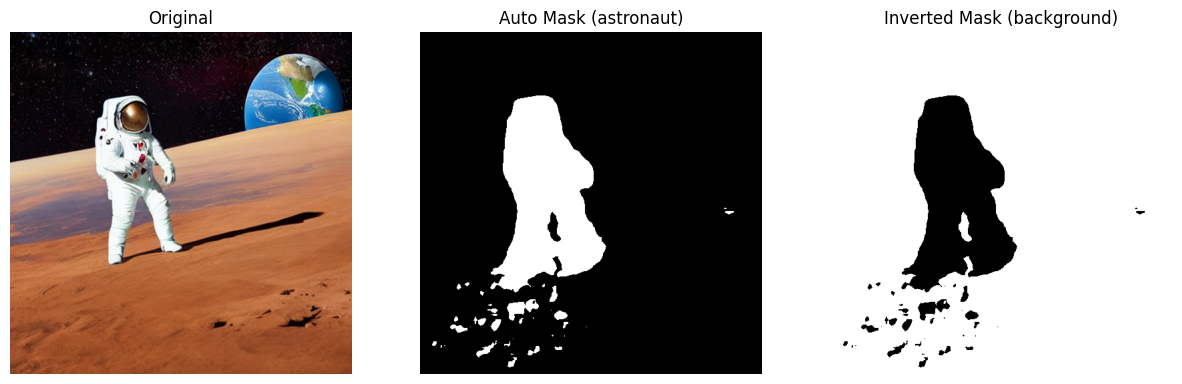

In [16]:
result_seg = segmentor(base_image)

# Cek label
for i, r in enumerate(result_seg):
    print(f"Index {i}: label={r['label']}, score={r['score']:.2f}")

# Ambil mask person (astronaut)
auto_mask = result_seg[1]["mask"].resize((512, 512)).convert("L")

# Invert — area putih = background yang akan di-inpaint
inverted_mask = PIL.ImageOps.invert(auto_mask)

# Tampilkan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(base_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(auto_mask, cmap="gray")
axes[1].set_title("Auto Mask (astronaut)")
axes[1].axis("off")

axes[2].imshow(inverted_mask, cmap="gray")
axes[2].set_title("Inverted Mask (background)")
axes[2].axis("off")
plt.show()

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

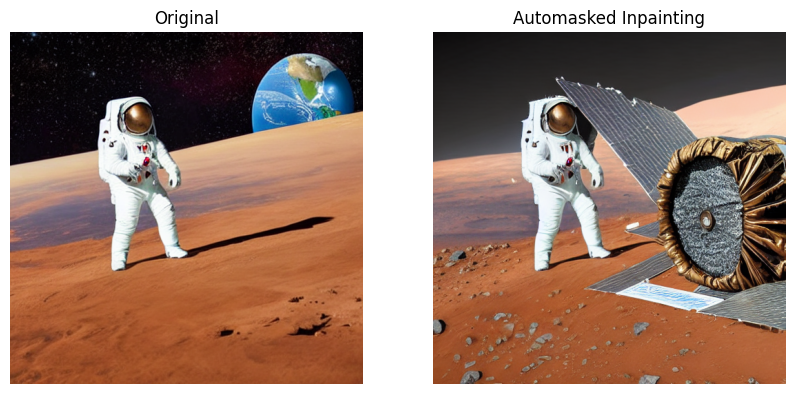

In [22]:
result_automasked = inpaint_engine(
    image=base_image,
    mask=inverted_mask,
    prompt="a broken damaged satellite spacecraft crashed on mars ground, bent metallic body, crumpled structure, sci-fi space probe, realistic, detailed",
    negative_prompt="blurry, cartoon, bad quality, deformed, person, human, astronaut",
    seed=9
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(base_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(result_automasked)
axes[1].set_title("Automasked Inpainting")
axes[1].axis("off")
plt.show()

## **Outpainting**

### **Prepare the Canvas**

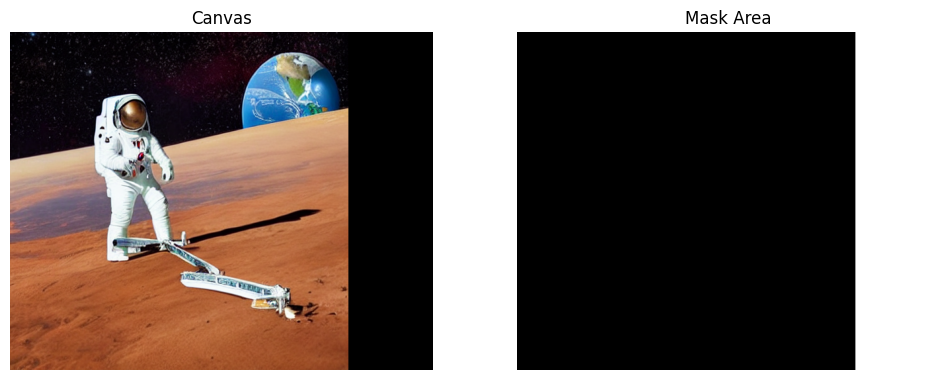

In [18]:
from PIL import Image
import numpy as np

def prepare_outpainting(image, direction="right", expand_px=128):
    """
    Memperluas kanvas ke satu arah tertentu.
    direction: "left", "right", "up", "down"
    expand_px: jumlah pixel yang ditambahkan
    """
    image = image.resize((512, 512)).convert("RGB")
    w, h = image.size

    if direction == "right":
        new_canvas = Image.new("RGB", (w + expand_px, h), color=(0, 0, 0))
        new_canvas.paste(image, (0, 0))
        mask_array = np.zeros((h, w + expand_px), dtype=np.uint8)
        mask_array[:, w:] = 255  # area kanan = di-generate

    elif direction == "left":
        new_canvas = Image.new("RGB", (w + expand_px, h), color=(0, 0, 0))
        new_canvas.paste(image, (expand_px, 0))
        mask_array = np.zeros((h, w + expand_px), dtype=np.uint8)
        mask_array[:, :expand_px] = 255

    elif direction == "down":
        new_canvas = Image.new("RGB", (w, h + expand_px), color=(0, 0, 0))
        new_canvas.paste(image, (0, 0))
        mask_array = np.zeros((h + expand_px, w), dtype=np.uint8)
        mask_array[h:, :] = 255

    elif direction == "up":
        new_canvas = Image.new("RGB", (w, h + expand_px), color=(0, 0, 0))
        new_canvas.paste(image, (0, expand_px))
        mask_array = np.zeros((h + expand_px, w), dtype=np.uint8)
        mask_array[:expand_px, :] = 255

    mask_pil = Image.fromarray(mask_array).convert("L")
    return new_canvas, mask_pil


# Test prepare canvas
canvas, outpaint_mask = prepare_outpainting(result_inpaint, direction="right", expand_px=128)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(canvas)
axes[0].set_title("Canvas")
axes[0].axis("off")

axes[1].imshow(outpaint_mask, cmap="gray")
axes[1].set_title("Mask Area")
axes[1].axis("off")
plt.show()

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

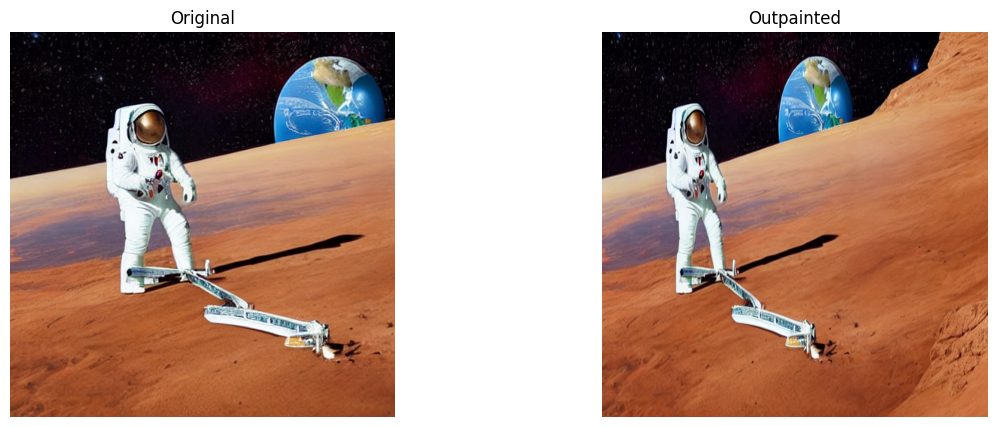

In [19]:
canvas, outpaint_mask = prepare_outpainting(result_inpaint, direction="right", expand_px=256)

canvas_768 = canvas.resize((768, 768)).convert("RGB")
mask_768 = outpaint_mask.resize((768, 768)).convert("L")

generator = torch.Generator("cuda").manual_seed(seed_value)

result_outpaint = pipe_inpaint(
    prompt="mars surface landscape, red rocky terrain, starry sky, continuation of the scene, realistic, detailed",
    negative_prompt="blurry, cartoon, bad quality, deformed, person, human",
    image=canvas_768,
    mask_image=mask_768,
    generator=generator,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=768,
    width=768
).images[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(result_inpaint)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(result_outpaint)
axes[1].set_title("Outpainted")
axes[1].axis("off")
plt.show()

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

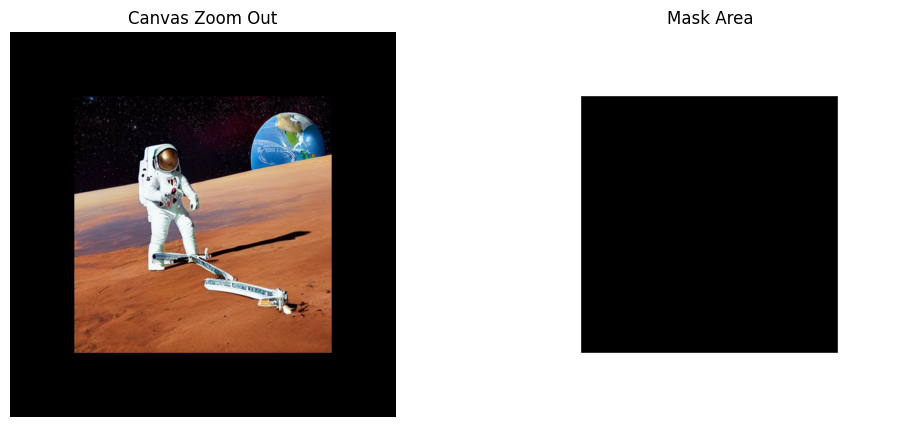

In [20]:
def prepare_zoom_out(image, expand_px=128):
    """
    Memperluas kanvas ke semua arah sekaligus untuk efek zoom out.
    """
    image = image.resize((512, 512)).convert("RGB")
    w, h = image.size

    new_w = w + expand_px * 2
    new_h = h + expand_px * 2

    new_canvas = Image.new("RGB", (new_w, new_h), color=(0, 0, 0))
    new_canvas.paste(image, (expand_px, expand_px))

    # Mask = semua area di luar gambar asli
    mask_array = np.ones((new_h, new_w), dtype=np.uint8) * 255
    mask_array[expand_px:expand_px+h, expand_px:expand_px+w] = 0
    mask_pil = Image.fromarray(mask_array).convert("L")

    return new_canvas, mask_pil

# Test canvas
canvas_zoom, mask_zoom = prepare_zoom_out(result_inpaint, expand_px=128)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(canvas_zoom)
axes[0].set_title("Canvas Zoom Out")
axes[0].axis("off")

axes[1].imshow(mask_zoom, cmap="gray")
axes[1].set_title("Mask Area")
axes[1].axis("off")
plt.show()

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

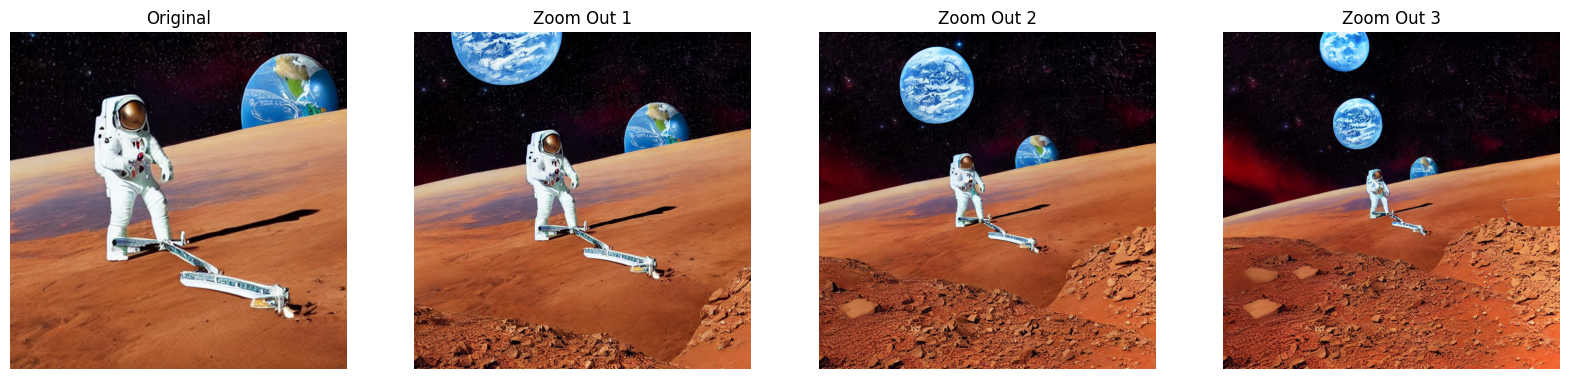

In [21]:
canvas_zoom_768 = canvas_zoom.resize((768, 768)).convert("RGB")
mask_zoom_768 = mask_zoom.resize((768, 768)).convert("L")

generator = torch.Generator("cuda").manual_seed(seed_value)

result_zoomout = pipe_inpaint(
    prompt="mars surface landscape, red rocky terrain, starry sky, wide angle view, continuation of the scene, realistic, detailed",
    negative_prompt="blurry, cartoon, bad quality, deformed, person, human",
    image=canvas_zoom_768,
    mask_image=mask_zoom_768,
    generator=generator,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=768,
    width=768
).images[0]

# Lakukan zoom out bertahap (3x)
current_image = result_inpaint
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(result_inpaint)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(3):
    canvas_z, mask_z = prepare_zoom_out(current_image, expand_px=128)
    canvas_z = canvas_z.resize((768, 768)).convert("RGB")
    mask_z = mask_z.resize((768, 768)).convert("L")
    
    generator = torch.Generator("cuda").manual_seed(seed_value)
    current_image = pipe_inpaint(
        prompt="mars surface landscape, red rocky terrain, starry sky, wide angle view, realistic, detailed",
        negative_prompt="blurry, cartoon, bad quality, deformed",
        image=canvas_z,
        mask_image=mask_z,
        generator=generator,
        num_inference_steps=50,
        guidance_scale=7.5,
        height=768,
        width=768
    ).images[0]
    
    axes[i+1].imshow(current_image)
    axes[i+1].set_title(f"Zoom Out {i+1}")
    axes[i+1].axis("off")

plt.show()